In [1]:
## Stochastic Simulation - Day 1

In [6]:
# Exercise 1 - Part 1: Write a program implementing a linear congruential generator (LCG).

import numpy as np

def lcg(x0, a, c, M, n):

    x = x0
    print(x)  # Print the initial value

    for _ in range(n):
        x = (a * x + c) % M
        print(x)


# Example from slides
x0 = 3
a = 5
c = 1
M = 16
n = 17

#lcg(x0, a, c, M, n)



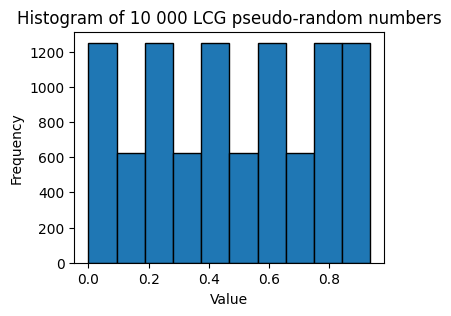

In [18]:
# Exercise 1 - Part 1: Generate 10.000 (pseudo-) random numbers and present these numbers in a histogramme (e.g. 10 classes).

import matplotlib.pyplot as plt

def lcg(x0, a, c, M, n):
    x = x0
    numbers = []

    for _ in range(n):
        x = (a * x + c) % M
        u = x / M
        numbers.append(u)

    return numbers


# Parameters
x0 = 3
a = 5
c = 1
M = 16
n = 10000

numbers = lcg(x0, a, c, M, n)

plt.figure(figsize=(4,3))
plt.hist(numbers, bins=10, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of 10 000 LCG pseudo-random numbers")
plt.show()

Runs = 5041
z = 0.8002980687714725
h=1: correlation=0.006419839646330917
h=2: correlation=-0.003928573578320284
h=5: correlation=0.003556855250545894
h=10: correlation=0.010089240745211846


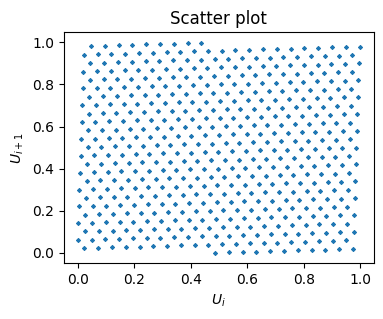

Chi-square statistic = 0.686
p-value = 0.9998828656976934
KS statistic = 0.002896875000000021
p-value = 0.9999958128547404
h=1: correlation=0.006419839646330917
h=2: correlation=-0.003928573578320284
h=5: correlation=0.003556855250545894
h=10: correlation=0.010089240745211846


In [22]:
# Exercise 1 - Part 1: Evaluate the quality of the generator 

import numpy as np
from scipy.stats import chisquare, kstest

# ---------- Run test: Above/Below ----------
# The run test checks for the number of runs above and below the median. 
median = np.median(numbers)
signs = numbers > median # Gives a boolean array where True means above the median and False means below the median

runs = 1 + np.sum(signs[1:] != signs[:-1]) # number of consecutive blocks of values that are on the same side of the median.

n1 = np.sum(signs)    # Number of runs above the median
n2 = len(signs) - n1  # Number of runs below the median

mu = 1 + 2*n1*n2/(n1+n2) #expected number of runs (mean-value)

sigma = np.sqrt(
    2*n1*n2*(2*n1*n2 - n1 - n2)
    / ((n1+n2)**2 * (n1+n2-1))
)

z = (runs - mu)/sigma # How many standard deviations the observed number of runs is from the 
                      # expected number of runs under the null hypothesis of randomness.

print("Runs =", runs)
print("z =", z)


# ---------- Correlation test ----------
for h in [1,2,5,10]:
    corr = np.corrcoef(numbers[:-h], numbers[h:])[0,1]
    print(f"h={h}: correlation={corr}")



# ---------- Scatter plot ----------
plt.figure(figsize=(4,3))
plt.scatter(numbers[:-1], numbers[1:], s=2)
plt.xlabel(r"$U_i$")
plt.ylabel(r"$U_{i+1}$")
plt.title("Scatter plot")
plt.show()


# ---------- Chi-square test ----------
counts, _ = np.histogram(numbers, bins=10, range=(0,1))
expected = np.full(10, len(numbers)/10)

chi2, p = chisquare(counts, expected)

print("Chi-square statistic =", chi2)
print("p-value =", p)


# ---------- Kolmogorov-Smirnov test ----------
ks, p = kstest(numbers, 'uniform')

print("KS statistic =", ks)
print("p-value =", p)


# ---------- Correlation tests ----------
for h in [1,2,5,10]:
    corr = np.corrcoef(numbers[:-h], numbers[h:])[0,1]
    print(f"h={h}: correlation={corr}")

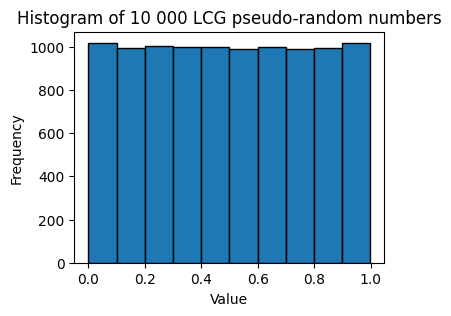

Runs = 5041
z = 0.8002980687714725
h=1: correlation=0.006419839646330917
h=2: correlation=-0.003928573578320284
h=5: correlation=0.003556855250545894
h=10: correlation=0.010089240745211846


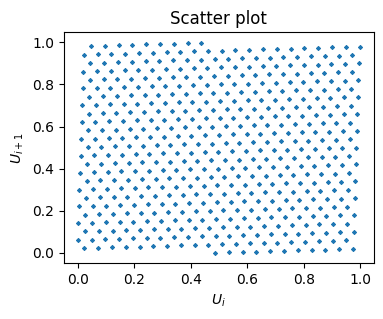

Chi-square statistic = 0.686
p-value = 0.9998828656976934
KS statistic = 0.002896875000000021
p-value = 0.9999958128547404
h=1: correlation=0.006419839646330917
h=2: correlation=-0.003928573578320284
h=5: correlation=0.003556855250545894
h=10: correlation=0.010089240745211846


In [23]:
# Repeat with different parameter values. Above is a bad parameter choice.
# Below is a better parameter choice (final one):

# Parameters
x0 = 1
a = 41
c = 31
M = 512
n = 10000

numbers = lcg(x0, a, c, M, n)

plt.figure(figsize=(4,3))
plt.hist(numbers, bins=10, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of 10 000 LCG pseudo-random numbers")
plt.show()

# ---------- Run test: Above/Below ----------
# The run test checks for the number of runs above and below the median. 
median = np.median(numbers)
signs = numbers > median # Gives a boolean array where True means above the median and False means below the median

runs = 1 + np.sum(signs[1:] != signs[:-1]) # number of consecutive blocks of values that are on the same side of the median.

n1 = np.sum(signs)    # Number of runs above the median
n2 = len(signs) - n1  # Number of runs below the median

mu = 1 + 2*n1*n2/(n1+n2) #expected number of runs (mean-value)

sigma = np.sqrt(
    2*n1*n2*(2*n1*n2 - n1 - n2)
    / ((n1+n2)**2 * (n1+n2-1))
)

z = (runs - mu)/sigma # How many standard deviations the observed number of runs is from the 
                      # expected number of runs under the null hypothesis of randomness.

print("Runs =", runs)
print("z =", z)


# ---------- Correlation test ----------
for h in [1,2,5,10]:
    corr = np.corrcoef(numbers[:-h], numbers[h:])[0,1]
    print(f"h={h}: correlation={corr}")



# ---------- Scatter plot ----------
plt.figure(figsize=(4,3))
plt.scatter(numbers[:-1], numbers[1:], s=2)
plt.xlabel(r"$U_i$")
plt.ylabel(r"$U_{i+1}$")
plt.title("Scatter plot")
plt.show()


# ---------- Chi-square test ----------
counts, _ = np.histogram(numbers, bins=10, range=(0,1))
expected = np.full(10, len(numbers)/10)

chi2, p = chisquare(counts, expected)

print("Chi-square statistic =", chi2)
print("p-value =", p)


# ---------- Kolmogorov-Smirnov test ----------
ks, p = kstest(numbers, 'uniform')

print("KS statistic =", ks)
print("p-value =", p)


# ---------- Correlation tests ----------
for h in [1,2,5,10]:
    corr = np.corrcoef(numbers[:-h], numbers[h:])[0,1]
    print(f"h={h}: correlation={corr}")

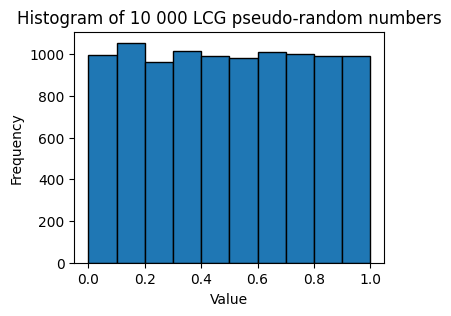

Runs = 4976
z = -0.5000250043757813
h=1: correlation=-0.003764840338809628
h=2: correlation=0.007686828034768538
h=5: correlation=-0.012183335239662788
h=10: correlation=-0.008673853085115344


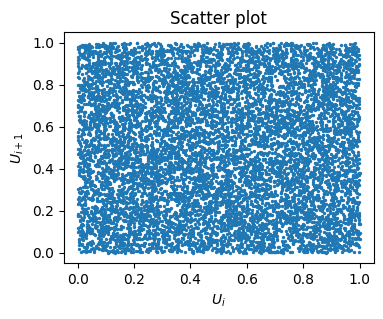

Chi-square statistic = 5.321999999999999
p-value = 0.805384064258083
KS statistic = 0.005423725670437141
p-value = 0.9286883879038645
h=1: correlation=-0.003764840338809628
h=2: correlation=0.007686828034768538
h=5: correlation=-0.012183335239662788
h=10: correlation=-0.008673853085115344


In [ ]:
# Exercise 1 - Part 2: Apply a system available generator and perform the tests from part 1 point (2) for this generator too.

import random  

numbers = [random.random() for _ in range(10000)] #using the Mersenne Twister generator, which is the default generator in Python's random module.

plt.figure(figsize=(4,3))
plt.hist(numbers, bins=10, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of 10 000 LCG pseudo-random numbers")
plt.show()

# ---------- Run test: Above/Below ----------
# The run test checks for the number of runs above and below the median. 
median = np.median(numbers)
signs = numbers > median # Gives a boolean array where True means above the median and False means below the median

runs = 1 + np.sum(signs[1:] != signs[:-1]) # number of consecutive blocks of values that are on the same side of the median.

n1 = np.sum(signs)    # Number of runs above the median
n2 = len(signs) - n1  # Number of runs below the median

mu = 1 + 2*n1*n2/(n1+n2) #expected number of runs (mean-value)

sigma = np.sqrt(
    2*n1*n2*(2*n1*n2 - n1 - n2)
    / ((n1+n2)**2 * (n1+n2-1))
)

z = (runs - mu)/sigma # How many standard deviations the observed number of runs is from the 
                      # expected number of runs under the null hypothesis of randomness.

print("Runs =", runs)
print("z =", z)


# ---------- Correlation test ----------
for h in [1,2,5,10]:
    corr = np.corrcoef(numbers[:-h], numbers[h:])[0,1]
    print(f"h={h}: correlation={corr}")



# ---------- Scatter plot ----------
plt.figure(figsize=(4,3))
plt.scatter(numbers[:-1], numbers[1:], s=2)
plt.xlabel(r"$U_i$")
plt.ylabel(r"$U_{i+1}$")
plt.title("Scatter plot")
plt.show()


# ---------- Chi-square test ----------
counts, _ = np.histogram(numbers, bins=10, range=(0,1))
expected = np.full(10, len(numbers)/10)

chi2, p = chisquare(counts, expected)

print("Chi-square statistic =", chi2)
print("p-value =", p)


# ---------- Kolmogorov-Smirnov test ----------
ks, p = kstest(numbers, 'uniform')

print("KS statistic =", ks)
print("p-value =", p)


# ---------- Correlation tests ----------
for h in [1,2,5,10]:
    corr = np.corrcoef(numbers[:-h], numbers[h:])[0,1]
    print(f"h={h}: correlation={corr}")